# E-Commerce - Linear Regression Project

This project uses 'Ecommerce customers' Data (Made-up data) of imaginary company that sells clothing online but they also have in-store style and clothing advice sessions. Customers come in to the store, have sessions/meetings with a personal stylist, then they can go home and order either on a mobile app or website for the clothes they want.

The Goal with this project is to help the company decide whether they should focus their efforts on their mobile app experience or their website.   

We will be using linear regression model to predict the 'Yearly Amount Spent' by the customers based on number of features. And on the basis of regression coefficients of the model, decide whether 'mobile app' or 'Website' results in greater 'Yearly Amount Spent' by the customers.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load The Data

In [2]:
customers = pd.read_csv('Ecommerce Customers')

In [3]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


### Exploratory Data Analysis

* Joint Plot  
  -->Compare 'Time on Website' and 'Yearly Amount Spent': 

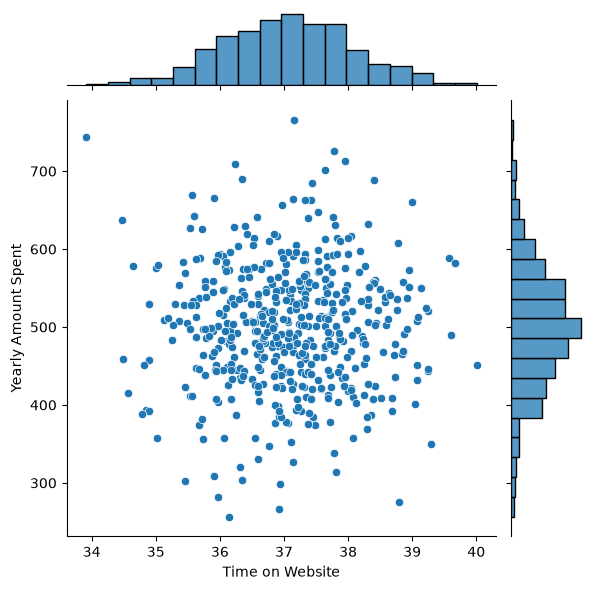

In [6]:
sns.jointplot(data=customers, x='Time on Website', y='Yearly Amount Spent')

* Joint Plot  
  -->Compare 'Time on App' and 'Yearly Amount Spent': 

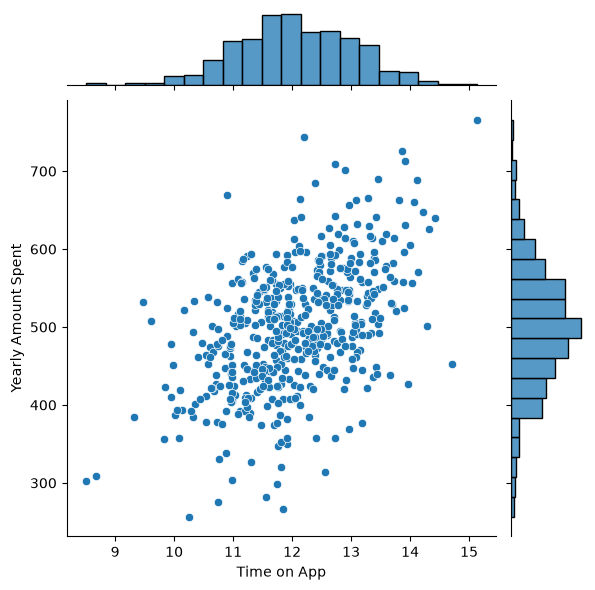

In [7]:
sns.jointplot(data=customers, x='Time on App', y='Yearly Amount Spent')

* Joint Plot (Hex)  
  -->Compare 'Time on App' and 'Length of Membership': 

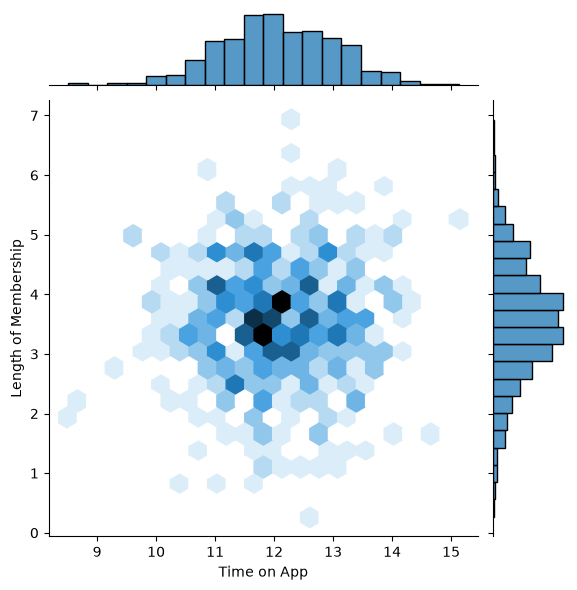

In [8]:
sns.jointplot(data=customers, x='Time on App', y='Length of Membership', kind='hex')

* PairPlot:

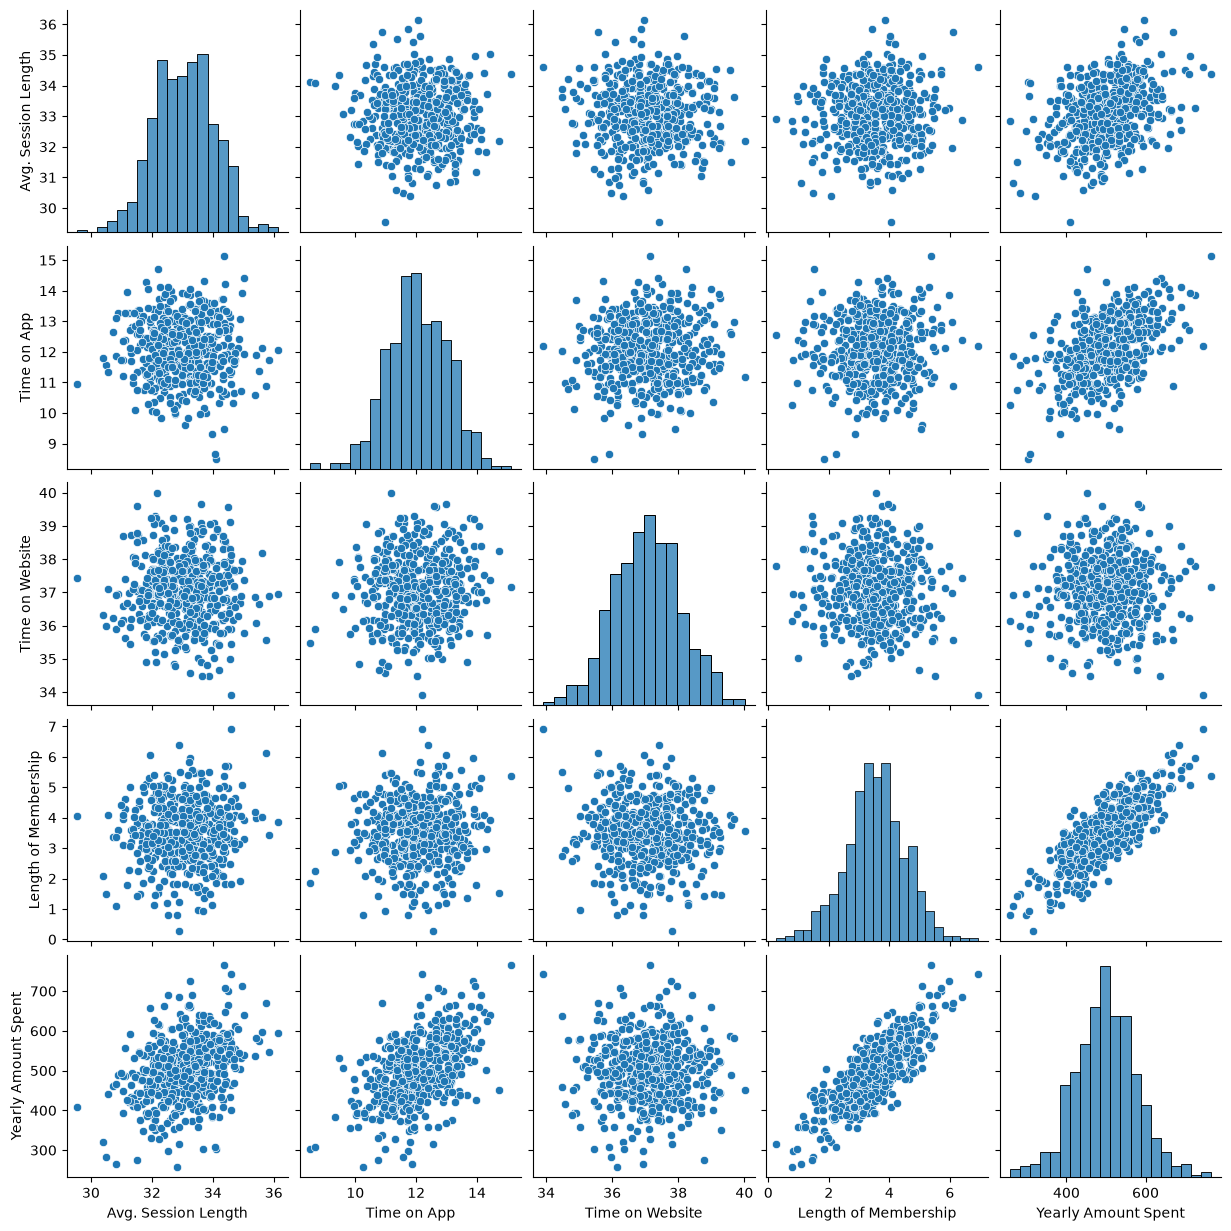

In [9]:
sns.pairplot(data=customers)

**Observation:** Based off this plot, we can tell that 'Length of Membership' is correlated with 'Yearly Amount Spent'. As the 'Length of Membership' increases, 'Yearly Amount Spent' too increases.

* Using seaborn's lmplot() - Creating a linear model plot of 'Yearly Amount Spent' vs. 'Length of Membership'.

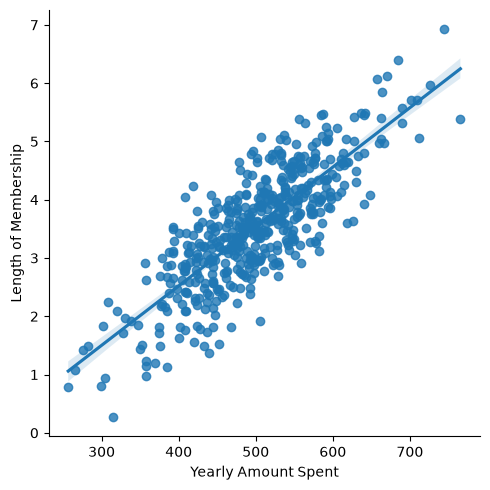

In [10]:
sns.lmplot(data=customers, x='Yearly Amount Spent', y='Length of Membership')

### Training and Testing Data

In [11]:
customers.head(2)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933


In [12]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = customers['Yearly Amount Spent']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### Training the Model

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
lm = LinearRegression()

In [18]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.98,38.59, 0.19,61.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1048
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [19]:
print("Coefficients:\n", lm.coef_) 

Coefficients:
 [25.98154972 38.59015875  0.19040528 61.27909654]


* Note: Last one(61.27...) is largest showing customers['Length of Membership'] is most correlated with 'Total Amount Spent'.

* Regression Coefficients:  
25.98154972 - Avg. Session Length  
38.59015875 - Time on App   
0.19040528 - Time on Website  
61.27909654 - Length of Membership

Interpreting Regression Coefficient:
A unit increase in 'Time on App'/'Time on Website'/'Length of Membership' results in an increase of respective 'regression coefficient' for 'Yearly Amount Spent'. (Holding all other features fixed)

### Predicting Test Data

In [20]:
y_pred = lm.predict(X_test)

* Scatter plot of real test values vs predicted test values

Text(0, 0.5, 'Y Predictions')

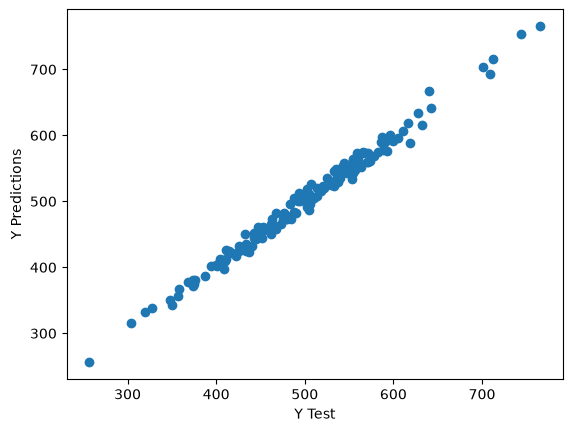

In [21]:
plt.scatter(x=y_test, y=y_pred)
plt.xlabel('Y Test')
plt.ylabel('Y Predictions')

### Evaluating the Model

Calculate:
* Mean Absolute Error
* Mean Squared Error
* Root Mean Squared Error

In [22]:
from sklearn import metrics

In [23]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', metrics.root_mean_squared_error(y_test, y_pred))

MAE: 7.2281486534308454
MSE: 79.81305165097454
RMSE: 8.933815066978639


### Residuals

* Using seaborn's histplot() - Plot a histogram of the residuals.

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

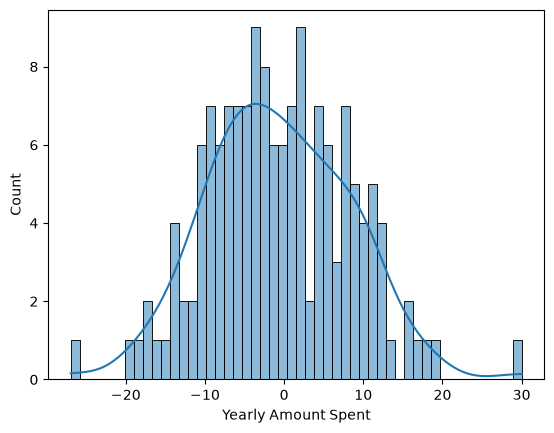

In [24]:
residuals = y_test - y_pred
sns.histplot(residuals, bins=50, kde=True)

**Observation:** Since the residual plot looks normally distributed, we can say that linear regression was the right choice for this problem.

### Conclusion


In [25]:
df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficients'])
df

,Coefficients
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


**Observation:** Based on the above the Regression Coefficients:   
1.Length of Membership has the most effect on the Amount spend by customers.   
2.Time on Mobile App is also a good indicator of increase in yearly spend by customer.   
3.In-store sessions/meetings with a personal stylist has also some significant positive relationship with cusomer's spending.  

**Conclusion:** Company should focus more on their mobile app. Website is barely increasing customer's Yearly Amount Spent
